In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)


In [ ]:
# DATASET LOADING & PREPROCESSING

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

MODEL DEFINITION

In [ ]:
def build_model(initializer, optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_initializer=initializer,
                              input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu',
                              kernel_initializer=initializer),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

PART A — WEIGHT INITIALIZATION COMPARISON

Random Normal + fixed(SGD Optimizer)

In [ ]:
model_random = build_model(
    tf.keras.initializers.RandomNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_random = model_random.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4850 - loss: 1.9361 - val_accuracy: 0.8183 - val_loss: 0.8069
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8390 - loss: 0.6957 - val_accuracy: 0.8823 - val_loss: 0.4551
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8823 - loss: 0.4467 - val_accuracy: 0.8973 - val_loss: 0.3706
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8965 - loss: 0.3765 - val_accuracy: 0.9058 - val_loss: 0.3325
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9052 - loss: 0.3413 - val_accuracy: 0.9120 - val_loss: 0.3089
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9105 - loss: 0.3184 - val_accuracy: 0.9166 - val_loss: 0.2917
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9151 - loss: 0.3011 - val_accuracy: 0.9207 - val_loss: 0.2782
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9189 - loss: 0.2871 - val_accuracy: 0.

Xavier Initialization + fixed(SGD Optimizer)

In [ ]:
model_xavier = build_model(
    tf.keras.initializers.GlorotUniform(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_xavier = model_xavier.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5005 - loss: 1.7305 - val_accuracy: 0.8401 - val_loss: 0.6162
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8545 - loss: 0.5615 - val_accuracy: 0.8917 - val_loss: 0.4057
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8889 - loss: 0.4051 - val_accuracy: 0.9061 - val_loss: 0.3400
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9016 - loss: 0.3483 - val_accuracy: 0.9139 - val_loss: 0.3067
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9109 - loss: 0.3167 - val_accuracy: 0.9199 - val_loss: 0.2850
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9163 - loss: 0.2950 - val_accuracy: 0.9217 - val_loss: 0.2689
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9206 - loss: 0.2781 - val_accuracy: 0.9254 - val_loss: 0.2559
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9249 - loss: 0.2641 - val_accuracy: 0.

He Initialization + fixed(SGD Optimizer)

In [ ]:
model_he = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_he = model_he.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5037 - loss: 1.6189 - val_accuracy: 0.8504 - val_loss: 0.5619
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8617 - loss: 0.5237 - val_accuracy: 0.8915 - val_loss: 0.3897
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8909 - loss: 0.3908 - val_accuracy: 0.9065 - val_loss: 0.3334
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9042 - loss: 0.3398 - val_accuracy: 0.9129 - val_loss: 0.3033
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9124 - loss: 0.3101 - val_accuracy: 0.9181 - val_loss: 0.2830
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9188 - loss: 0.2888 - val_accuracy: 0.9222 - val_loss: 0.2674
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9240 - loss: 0.2721 - val_accuracy: 0.9261 - val_loss: 0.2546
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9278 - loss: 0.2581 - val_accuracy: 0.

Initialization Comparison Plots

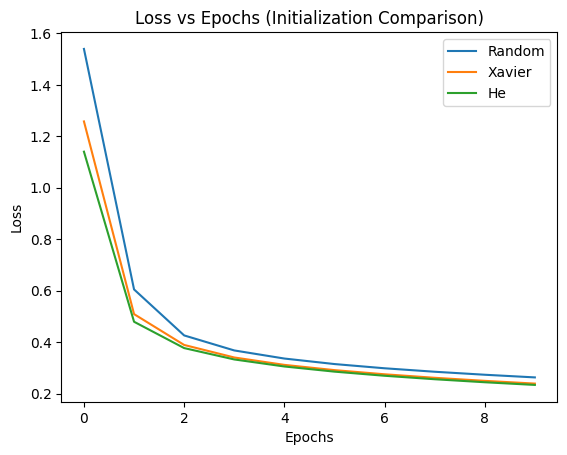

In [ ]:
plt.plot(history_random.history['loss'], label='Random')
plt.plot(history_xavier.history['loss'], label='Xavier')
plt.plot(history_he.history['loss'], label='He')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Initialization Comparison)")
plt.legend()
plt.show()

PART B — OPTIMIZER COMPARISON

Adam Optimizer with Best Initialization

In [ ]:
model_adam = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.Adam()
)

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8327 - loss: 0.6040 - val_accuracy: 0.9533 - val_loss: 0.1584
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9584 - loss: 0.1447 - val_accuracy: 0.9639 - val_loss: 0.1202
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9718 - loss: 0.0973 - val_accuracy: 0.9685 - val_loss: 0.0975
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9792 - loss: 0.0719 - val_accuracy: 0.9713 - val_loss: 0.0871
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9843 - loss: 0.0551 - val_accuracy: 0.9744 - val_loss: 0.0824
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9887 - loss: 0.0424 - val_accuracy: 0.9739 - val_loss: 0.0848
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9907 - loss: 0.0340 - val_accuracy: 0.9727 - val_loss: 0.0891
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9921 - loss: 0.0276 - val_accuracy: 0


Optimizer Comparison Plot

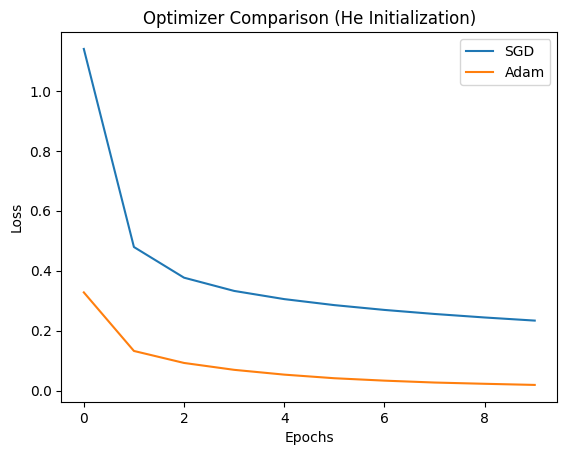

In [ ]:
plt.plot(history_he.history['loss'], label='SGD')
plt.plot(history_adam.history['loss'], label='Adam')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (He Initialization)")
plt.legend()
plt.show()
